## Simpler NN model (for demonstration)

### Load dataset

In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras.datasets import mnist
from sklearn.model_selection import train_test_split

np.random.seed(0)

(x_train, y_train), (x_test, y_test) = mnist.load_data()  # Load ONLY TRAINING data

# Split the data into training and testing sets (80-20 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=42) #random_state makes the split consistent.

### Prepare data

In [9]:
num_classes = 10
# one-hot vector encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
# Normalize data
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

# Reshape data
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# After reshaping
x_train.shape

(48000, 784)

### Create simpler model- Neural Network

In [10]:
model = Sequential()

model.add(Dense(units = 128, activation='relu', input_shape=(784,)))
model.add(Dense(units = 128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units = 10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [11]:
batch_size = 512
epochs = 10
model.fit(x = x_train, y=y_train, batch_size = batch_size, epochs=epochs)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6590 - loss: 1.1713
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9209 - loss: 0.2706
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9442 - loss: 0.1919
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9564 - loss: 0.1532
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9661 - loss: 0.1200
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9692 - loss: 0.1061
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9729 - loss: 0.0956
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9771 - loss: 0.0786
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9799 - loss: 0.0692
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9817 - loss: 0.0617


### Evaluate Model performance

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9752 - loss: 0.0831
Test Loss: 0.0839560478925705
Test Accuracy: 0.9750000238418579


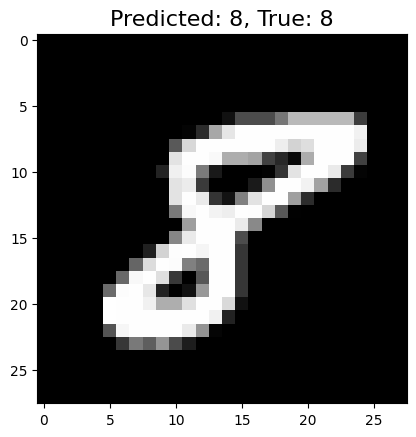

In [18]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Single Example
random_idx = np.random.choice(len(x_test))
x_sample = x_test[random_idx]
y_true = np.argmax(y_test, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred_class = y_pred_classes[random_idx]

plt.title('Predicted: {}, True: {}'.format(y_sample_pred_class, y_sample_true),
          fontsize=16)
plt.imshow(x_sample.reshape(28,28), cmap='gray')

# Evaluation
test_loss,test_acc = model.evaluate(x_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


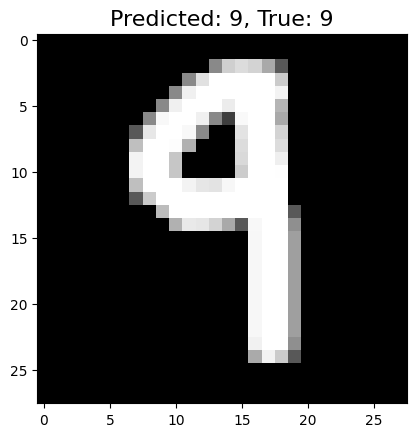

In [17]:
# External Example

from PIL import Image

def preprocess_image(image_path):
    """Loads, preprocesses, and returns an image as a NumPy array (flattened)."""
    img = Image.open(image_path).convert('L')  # Load as grayscale
    img = img.resize((28, 28))
    img_array = np.array(img)
    img_array = img_array / 255.0  # Normalize to [0, 1]
    img_array = img_array.reshape(1, 784)  # Flatten and add batch dimension
    return img_array

image_path = "externalSample_9.png"
input_image = preprocess_image(image_path)

prediction = model.predict(input_image)
true_label = 9
predicted_label = np.argmax(prediction)

plt.title('Predicted: {}, True: {}'.format(predicted_label, true_label),
          fontsize=16)
plt.imshow(input_image.reshape(28,28), cmap='gray')